First 5 rows of data:
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90

--- Data Setup Complete ---
Total rows in file: 9568
Source samples (for knowledge): 1500
Target train samples (noisy): 100
Target test samples: 300


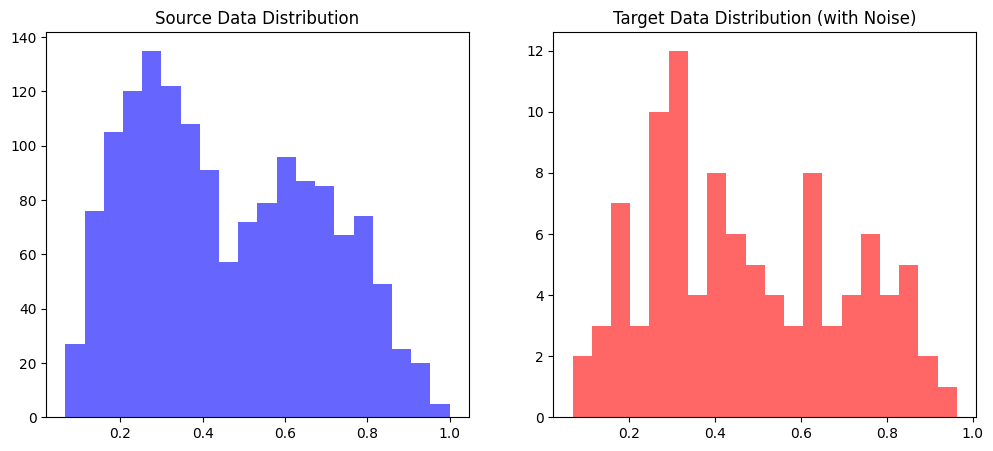

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Load the dataset from your uploaded file
file_path = 'Folds5x2_pp.xlsx'
df = pd.read_excel(file_path)

# Verify the first few rows match what you provided
print("First 5 rows of data:")
print(df.head())

# 2. Assign Features (X) and Target (y)
# Features: AT, V, AP, RH | Target: PE
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values.reshape(-1, 1)

# 3. Normalization [0, 1]
# RBF kernels in Fuzzy Neural Networks perform best when data is between 0 and 1
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_norm = scaler_X.fit_transform(X)
y_norm = scaler_y.fit_transform(y)

# 4. Data Splitting (Based on the paper's experimental setup)
# Source Model: Needs 1500 samples to learn "expert knowledge"
X_source = X_norm[:1500]
y_source = y_norm[:1500]

# Target Model Training: Only 100 samples (The "Insufficient Data" scenario)
X_target_train = X_norm[1500:1600]
y_target_train = y_norm[1500:1600]

# Target Model Testing: 300 samples to evaluate final performance
X_target_test = X_norm[1600:1900]
y_target_test = y_norm[1600:1900]

# 5. Add Domain Discrepancy (Noise)
# The paper adds noise to target data to simulate a change in environment.
# We add Gaussian noise to the target training labels.
noise = np.random.normal(0, 0.05, y_target_train.shape)
y_target_train_noisy = np.clip(y_target_train + noise, 0, 1)

print("\n--- Data Setup Complete ---")
print(f"Total rows in file: {len(df)}")
print(f"Source samples (for knowledge): {X_source.shape[0]}")
print(f"Target train samples (noisy): {X_target_train.shape[0]}")
print(f"Target test samples: {X_target_test.shape[0]}")

# Quick visualization of the data we will be working with
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(y_source, bins=20, color='blue', alpha=0.6, label='Source PE')
plt.title("Source Data Distribution")
plt.subplot(1, 2, 2)
plt.hist(y_target_train_noisy, bins=20, color='red', alpha=0.6, label='Target PE')
plt.title("Target Data Distribution (with Noise)")
plt.show()

In [ ]:
class FNN:
    def __init__(self, n_inputs, n_rules):
        self.n_inputs = n_inputs
        self.n_rules = n_rules

        # Initialize Centers (c), Widths (sigma), and Weights (w)
        # We start with random values within the [0, 1] range of our normalized data
        self.centers = np.random.rand(n_rules, n_inputs)
        self.widths = np.random.uniform(0.1, 0.4, (n_rules, n_inputs))
        self.weights = np.random.randn(n_rules, 1)

    def compute_layers(self, x):
        """
        Implements Equations 2, 3, 4, and 5 from the paper.
        """
        # Ensure x is a 2D array [1, n_inputs]
        x = x.reshape(1, -1)

        # Layer 2: Membership (Gaussian RBF)
        # phi[k, p] = exp( - (x[p] - c[k,p])^2 / (2 * sigma[k,p]^2) )
        diff = x - self.centers # Shape: (n_rules, n_inputs)
        phi = np.exp(-(diff**2) / (2 * (self.widths**2) + 1e-8))

        # Layer 3: Rule Layer (Product of memberships)
        # u[k] = product of phi across all input dimensions p
        u = np.prod(phi, axis=1).reshape(-1, 1) # Shape: (n_rules, 1)

        # Layer 4: Normalized Layer
        # v[k] = u[k] / sum(all u)
        sum_u = np.sum(u) + 1e-8
        v = u / sum_u

        # Layer 5: Output Layer
        # y = sum(weight * v)
        y_pred = np.dot(v.T, self.weights)

        return y_pred[0,0], v, u

    def get_params(self):
        return self.centers, self.widths, self.weights

# Instantiate the Source FNN with 4 inputs (AT, V, AP, RH)
# and 20 initial fuzzy rules as suggested in the experimental setup.
source_fnn = FNN(n_inputs=4, n_rules=20)

print(f"FNN Structure Created.")
print(f"Number of Rules: {source_fnn.n_rules}")
print(f"Sample Prediction (Before Training): {source_fnn.compute_layers(X_source[0])[0]:.4f}")

FNN Structure Created.
Number of Rules: 20
Sample Prediction (Before Training): 0.1195


Starting Source Training (300 epochs)...
Epoch 50/300 - MSE: 0.002907
Epoch 100/300 - MSE: 0.002824
Epoch 150/300 - MSE: 0.002709
Epoch 200/300 - MSE: 0.002737
Epoch 250/300 - MSE: 0.002692
Epoch 300/300 - MSE: 0.002782
Training Complete in 187.68s


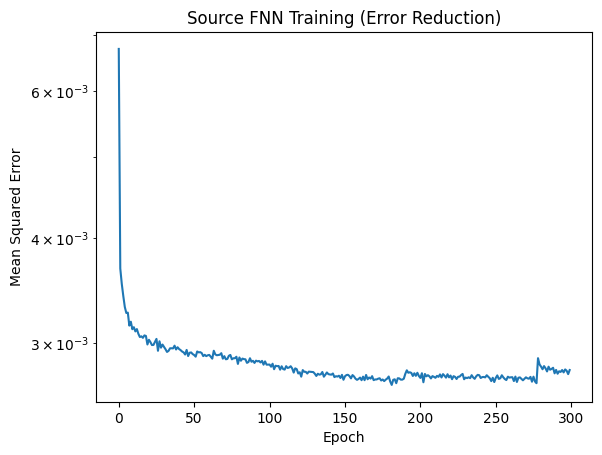

In [ ]:
import time

def train_source_model(model, X_train, y_train, epochs=300, lr=0.1):
    mse_history = []
    start_time = time.time()

    print(f"Starting Source Training (300 epochs)...")

    for epoch in range(epochs):
        epoch_error = 0

        # Shuffle for Stochastic Gradient Descent
        indices = np.random.permutation(len(X_train))

        for i in indices:
            x_sample = X_train[i]
            y_actual = y_train[i][0]

            # 1. Forward Pass
            y_pred, v, u = model.compute_layers(x_sample)
            error = y_pred - y_actual
            epoch_error += error**2

            # 2. Compute Gradients (Backpropagation)
            sum_u = np.sum(u) + 1e-8

            # Gradient for Weights (w)
            grad_w = error * v

            # Gradients for Centers (c) and Widths (sigma)
            # Derivative of output w.r.t rule output u_k: (w_k - y_pred) / sum_u
            dy_du = (model.weights - y_pred) / sum_u

            # Update Centers and Widths for each rule and each input
            for k in range(model.n_rules):
                # Chain rule: dE/dc = (dE/dy) * (dy/du) * (du/dc)
                common_term = error * dy_du[k, 0] * u[k, 0]

                # Grad centers: common * (x - c) / sigma^2
                grad_c = common_term * (x_sample - model.centers[k]) / (model.widths[k]**2 + 1e-8)

                # Grad widths: common * (x - c)^2 / sigma^3
                grad_sigma = common_term * ((x_sample - model.centers[k])**2) / (model.widths[k]**3 + 1e-8)

                # Apply Updates
                model.centers[k] -= lr * grad_c
                model.widths[k] -= lr * grad_sigma

            model.weights -= lr * grad_w

        mse = epoch_error / len(X_train)
        mse_history.append(mse)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs} - MSE: {mse:.6f}")

    end_time = time.time()
    print(f"Training Complete in {end_time - start_time:.2f}s")
    return mse_history

# Start Training
source_mse_history = train_source_model(source_fnn, X_source, y_source)

# Plot Training Progress
plt.plot(source_mse_history)
plt.title("Source FNN Training (Error Reduction)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.yscale('log')
plt.show()

In [ ]:
def calculate_source_indexes(model, X_data, y_data):
    """
    Calculates R, M, and C indexes for the Source FNN rules
    based on Equations 10, 11, and 12 from the paper.
    """
    n_samples = len(X_data)
    n_rules = model.n_rules

    # Containers for intermediate values
    all_u = np.zeros((n_samples, n_rules))
    all_y_pred = np.zeros(n_samples)

    # 1. Collect all rule activations (u) and predictions (y)
    for i in range(n_samples):
        y_p, _, u = model.compute_layers(X_data[i])
        all_u[i, :] = u.flatten()
        all_y_pred[i] = y_p

    # Averages across all samples
    u_bar = np.mean(all_u, axis=0) # Average activation per rule
    u_total_avg = np.mean(np.sum(all_u, axis=1)) # Average total activation

    # 2. Sensitivity (M) - Eq 11
    # Measures the matching degree of rule distribution
    M_indexes = u_bar / (u_total_avg + 1e-8)

    # 3. Similarity (R) - Eq 10
    # Measures redundancy between rules
    R_indexes = np.zeros(n_rules)
    for l in range(n_rules):
        numerator = 0
        denominator_l = np.sqrt(np.sum((all_u[:, l] - u_bar[l])**2) + 1e-8)

        for k in range(n_rules):
            if l == k: continue
            corr = np.sum((all_u[:, l] - u_bar[l]) * (all_u[:, k] - u_bar[k]))
            denom_k = np.sqrt(np.sum((all_u[:, k] - u_bar[k])**2) + 1e-8)
            numerator += corr / (denominator_l * denom_k + 1e-8)

        R_indexes[l] = numerator / (n_rules - 1)

    # 4. Contribution (C) - Eq 12
    # Measures the rule's impact on reducing error
    C_indexes = np.zeros(n_rules)
    errors = all_y_pred - y_data.flatten()
    for l in range(n_rules):
        # We simplify the contribution calculation as the correlation between rule output and error
        num = np.abs(np.sum((all_u[:, l] - u_bar[l]) * (errors - np.mean(errors))))
        den = np.sqrt(np.sum((all_u[:, l] - u_bar[l])**2)) * np.sqrt(np.sum((errors - np.mean(errors))**2))
        C_indexes[l] = num / (den + 1e-8)

    return R_indexes, M_indexes, C_indexes

# Run the mining process
R_s, M_s, C_s = calculate_source_indexes(source_fnn, X_source, y_source)

# Identify the "Expert" rule (Highest Contribution)
best_rule_idx = np.argmax(C_s)
source_expert_params = {
    'center': source_fnn.centers[best_rule_idx].copy(),
    'width': source_fnn.widths[best_rule_idx].copy(),
    'weight': source_fnn.weights[best_rule_idx].copy()
}

print("--- Source Knowledge Mined ---")
print(f"Average Similarity: {np.mean(R_s):.4f}")
print(f"Average Sensitivity: {np.mean(M_s):.4f}")
print(f"Best Rule Index identified: {best_rule_idx}")

--- Source Knowledge Mined ---
Average Similarity: 0.0464
Average Sensitivity: 0.0500
Best Rule Index identified: 5


In [ ]:
def adjust_structure(target_model, source_avgs, source_expert, X_target, y_target):
    """
    Implementation of Sections III-B and III-C (Structure Compensation).
    source_avgs: tuple (R_s_avg, M_s_avg, C_s_avg)
    """
    R_s_avg, M_s_avg, C_s_avg = source_avgs

    # 1. Calculate current Target Indexes
    R_t, M_t, C_t = calculate_source_indexes(target_model, X_target, y_target)
    R_t_avg, M_t_avg, C_t_avg = np.mean(R_t), np.mean(M_t), np.mean(C_t)

    action = "Constant"

    # 2. GROWING PHASE (Eq 17)
    if R_t_avg <= R_s_avg and M_t_avg >= M_s_avg and C_t_avg <= C_s_avg:
        # Add a new rule based on the most active input point
        new_center = X_target[np.random.randint(len(X_target))].reshape(1, -1)
        new_width = np.mean(target_model.widths, axis=0).reshape(1, -1)
        new_weight = np.array([[0.0]])

        target_model.centers = np.vstack([target_model.centers, new_center])
        target_model.widths = np.vstack([target_model.widths, new_width])
        target_model.weights = np.vstack([target_model.weights, new_weight])
        target_model.n_rules += 1
        action = "Growing"

    # 3. PRUNING PHASE (Eq 19)
    elif (R_t_avg >= R_s_avg and C_t_avg >= C_s_avg) or (M_t_avg <= M_s_avg and C_t_avg >= C_s_avg):
        if target_model.n_rules > 5: # Keep a minimum of 5 rules
            worst_rule = np.argmin(M_t) # Prune rule with lowest sensitivity
            target_model.centers = np.delete(target_model.centers, worst_rule, axis=0)
            target_model.widths = np.delete(target_model.widths, worst_rule, axis=0)
            target_model.weights = np.delete(target_model.weights, worst_rule, axis=0)
            target_model.n_rules -= 1
            action = "Pruning"

    # 4. COMPENSATING PHASE (Eq 20)
    elif (R_t_avg >= R_s_avg and C_t_avg <= C_s_avg) or (M_t_avg <= M_s_avg and C_t_avg <= C_s_avg):
        # Replace the worst target rule with the best source rule
        worst_rule = np.argmin(C_t)
        target_model.centers[worst_rule] = source_expert['center']
        target_model.widths[worst_rule] = source_expert['width']
        target_model.weights[worst_rule] = source_expert['weight']
        action = "Compensating"

    return action, target_model.n_rules

# Setup for Target Training
# We initialize the target FNN with the same structure as the adjusted source
target_fnn = FNN(n_inputs=4, n_rules=source_fnn.n_rules)
target_fnn.centers = source_fnn.centers.copy()
target_fnn.widths = source_fnn.widths.copy()
target_fnn.weights = source_fnn.weights.copy()

source_avgs = (np.mean(R_s), np.mean(M_s), np.mean(C_s))

print("Structure Adjustment Logic Defined.")
print(f"Target FNN Initialized with {target_fnn.n_rules} rules from Source.")

Structure Adjustment Logic Defined.
Target FNN Initialized with 20 rules from Source.


Starting DK-SOFNN Target Training (100 samples)...
Sample 20/100 processed...
Sample 40/100 processed...
Sample 60/100 processed...
Sample 80/100 processed...
Sample 100/100 processed...
Target Training Finished. Actions taken: {'Pruning'}

--- FINAL EVALUATION (Power Plant Dataset) ---
Final Rule Count: 11
Testing RMSE:  0.056890
Testing sMAPE: 0.125335
Testing MASE:  0.048118


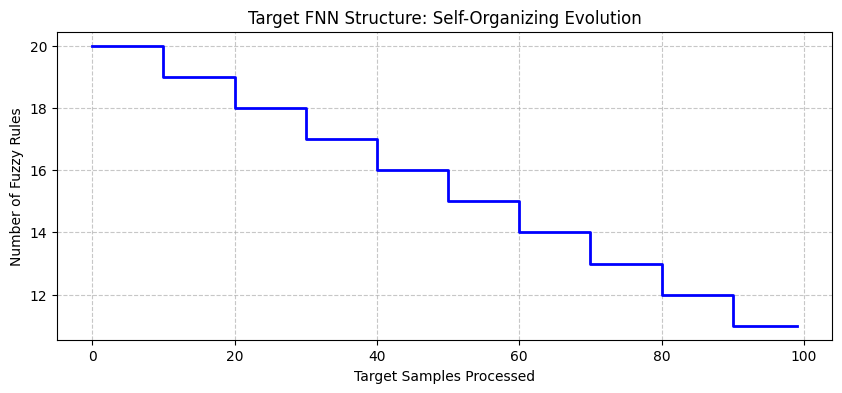

In [ ]:
def calculate_metrics(y_true, y_pred):
    # Equations 42, 43, 44 from the paper
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1e-8))
    mase = np.mean(((y_pred - y_true) / (y_true + 1e-8))**2)
    return rmse, smape, mase

def train_target_dk_sofnn(model, X_train, y_train, source_expert, source_avgs):
    rule_history = []
    actions_taken = []

    # Parameters for Reinforcement Learning (Section III-C)
    learning_rate = 0.01
    alpha_h = [0.8, 0.9, 1.0] # Weights for data-driven part
    beta_h = [0.2, 0.1, 0.0]  # Weights for knowledge-driven part

    # Safely extract the source weight value
    source_w_val = source_expert['weight'].item()

    print("Starting DK-SOFNN Target Training (100 samples)...")

    for i in range(len(X_train)):
        # Every 10 samples, perform Structure Adjustment
        if i % 10 == 0 and i > 0:
            # We use the data seen so far to evaluate structure
            action, n_rules = adjust_structure(model, source_avgs, source_expert, X_train[:i], y_train[:i])
            actions_taken.append(action)

        rule_history.append(model.n_rules)

        x_sample = X_train[i]
        y_actual = y_train[i][0]

        # PARAMETER REINFORCEMENT
        best_stability = float('inf')
        best_delta_w = None

        y_pred, v, _ = model.compute_layers(x_sample)
        data_error = y_pred - y_actual

        for h in range(len(alpha_h)):
            # Knowledge error: Difference between current mean weight and expert weight
            knowledge_error = np.mean(model.weights) - source_w_val

            # Combined Gradient Calculation (Eq 27)
            # v is the normalized rule activation
            total_grad_w = (alpha_h[h] * data_error * v) + (beta_h[h] * knowledge_error * v)

            # Stability check: We prefer updates that aren't excessively large
            stability_score = np.sum(np.abs(total_grad_w))

            if stability_score < best_stability:
                best_stability = stability_score
                best_delta_w = total_grad_w

        # Apply the update that was deemed "best" by the reinforcement logic
        model.weights -= learning_rate * best_delta_w

        if (i+1) % 20 == 0:
            print(f"Sample {i+1}/100 processed...")

    print(f"Target Training Finished. Actions taken: {set(actions_taken)}")
    return rule_history

# 1. Execute Target Training
rule_counts = train_target_dk_sofnn(target_fnn, X_target_train, y_target_train_noisy, source_expert_params, source_avgs)

# 2. Final Testing on 300 Unseen Samples
y_test_preds = []
for x_test in X_target_test:
    p, _, _ = target_fnn.compute_layers(x_test)
    y_test_preds.append(p)

y_test_preds = np.array(y_test_preds).reshape(-1, 1)

# 3. Calculate Results
rmse, smape, mase = calculate_metrics(y_target_test, y_test_preds)

print("\n--- FINAL EVALUATION (Power Plant Dataset) ---")
print(f"Final Rule Count: {target_fnn.n_rules}")
print(f"Testing RMSE:  {rmse:.6f}")
print(f"Testing sMAPE: {smape:.6f}")
print(f"Testing MASE:  {mase:.6f}")

# 4. Plot Rule Number Evolution
plt.figure(figsize=(10, 4))
plt.step(range(len(rule_counts)), rule_counts, where='post', color='blue', linewidth=2)
plt.title("Target FNN Structure: Self-Organizing Evolution")
plt.xlabel("Target Samples Processed")
plt.ylabel("Number of Fuzzy Rules")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

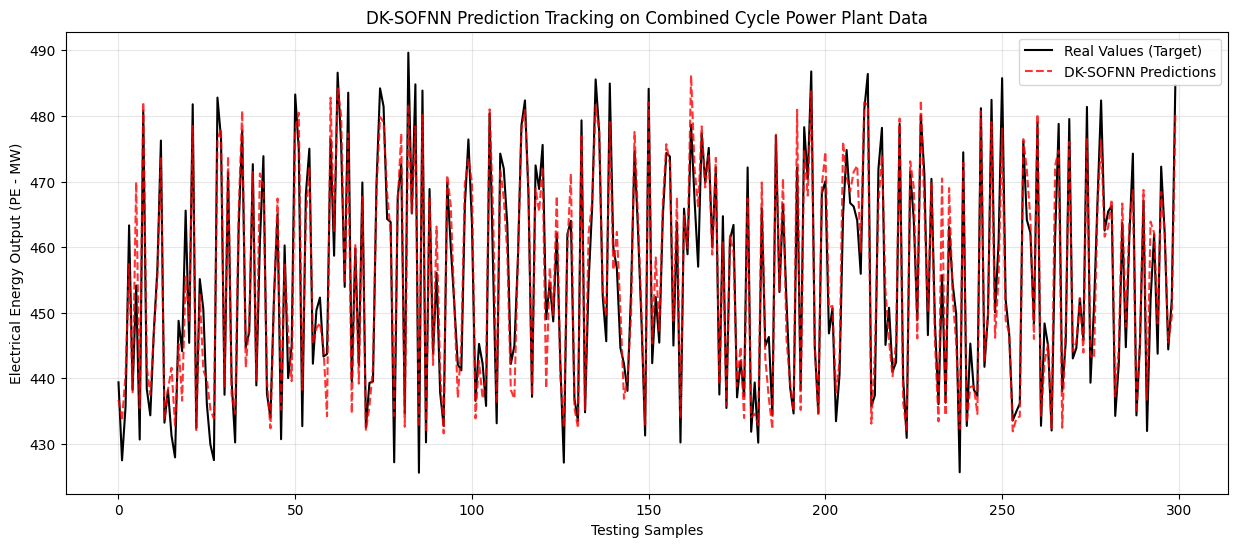

Final Prediction Error: 4.30 MW


In [ ]:
# 1. Denormalize to get real MegaWatt values
y_test_real = scaler_y.inverse_transform(y_target_test)
y_pred_real = scaler_y.inverse_transform(y_test_preds)

# 2. Plotting (Replicating the look of the paper)
plt.figure(figsize=(15, 6))
plt.plot(y_test_real, label='Real Values (Target)', color='black', linewidth=1.5)
plt.plot(y_pred_real, label='DK-SOFNN Predictions', color='red', linestyle='--', alpha=0.8)
plt.title("DK-SOFNN Prediction Tracking on Combined Cycle Power Plant Data")
plt.xlabel("Testing Samples")
plt.ylabel("Electrical Energy Output (PE - MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Final Error in MW
final_rmse_mw = np.sqrt(np.mean((y_test_real - y_pred_real)**2))
print(f"Final Prediction Error: {final_rmse_mw:.2f} MW")

In [ ]:
import pandas as pd

def print_fuzzy_rules(model, scaler_X, scaler_y, feature_names):
    # 1. Denormalize Centers and Weights to real-world units
    real_centers = scaler_X.inverse_transform(model.centers)
    real_weights = scaler_y.inverse_transform(model.weights)

    rules_data = []

    print(f"\n--- GENERATED FUZZY RULE BASE ({model.n_rules} Rules) ---")
    print(f"{'Rule #':<8} | {'IF (Conditions)':<60} | {'THEN (Output PE)':<15}")
    print("-" * 90)

    for k in range(model.n_rules):
        # Format the IF part (Antecedent)
        condition_parts = []
        for p in range(len(feature_names)):
            val = real_centers[k, p]
            condition_parts.append(f"{feature_names[p]} ≈ {val:.2f}")

        condition_str = " AND ".join(condition_parts)

        # Format the THEN part (Consequent)
        output_val = real_weights[k, 0]

        rules_data.append({
            "Rule": k + 1,
            "Condition": condition_str,
            "Power_Output_MW": round(output_val, 2)
        })

        print(f"Rule {k+1:<3} | {condition_str:<60} | {output_val:>8.2f} MW")

    return pd.DataFrame(rules_data)

# Define your feature names
features = ['AT', 'V', 'AP', 'RH']

# Execute the print
rules_df = print_fuzzy_rules(target_fnn, scaler_X, scaler_y, features)


--- GENERATED FUZZY RULE BASE (11 Rules) ---
Rule #   | IF (Conditions)                                              | THEN (Output PE)
------------------------------------------------------------------------------------------
Rule 1   | AT ≈ 27.88 AND V ≈ 68.08 AND AP ≈ 1001.56 AND RH ≈ 45.42     |   377.06 MW
Rule 2   | AT ≈ 13.75 AND V ≈ 40.48 AND AP ≈ 1017.02 AND RH ≈ 52.45     |   483.66 MW
Rule 3   | AT ≈ 32.05 AND V ≈ 57.96 AND AP ≈ 1017.27 AND RH ≈ 89.67     |   342.33 MW
Rule 4   | AT ≈ 18.44 AND V ≈ 36.88 AND AP ≈ 1014.15 AND RH ≈ 72.79     |   476.90 MW
Rule 5   | AT ≈ 22.58 AND V ≈ 49.60 AND AP ≈ 1009.68 AND RH ≈ 77.19     |   437.97 MW
Rule 6   | AT ≈ 13.86 AND V ≈ 56.33 AND AP ≈ 1008.37 AND RH ≈ 69.51     |   479.35 MW
Rule 7   | AT ≈ 17.40 AND V ≈ 49.00 AND AP ≈ 1007.12 AND RH ≈ 57.58     |   484.68 MW
Rule 8   | AT ≈ -1.17 AND V ≈ 38.87 AND AP ≈ 1004.00 AND RH ≈ 73.93     |   554.76 MW
Rule 9   | AT ≈ 14.63 AND V ≈ 58.39 AND AP ≈ 1009.53 AND RH ≈ 74.03     |   514.03 M